# Support Vector Machine (SVM)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_linear_coefficients, plot_sweep_decision_scores,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid_svm = run_grid_search(
    SVC(kernel="linear", class_weight=class_weight_dict, probability=True, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
svm_l = grid_svm.best_estimator_

y_pred_svm = svm_l.predict(X_test_scaled)
y_prob_svm = svm_l.predict_proba(X_test_scaled)
y_dec_svm  = svm_l.decision_function(X_test_scaled)

class_names, classes, colors = get_class_meta()

print("Linear SVM training complete.")
print(f"Best C used: {grid_svm.best_params_['C']}")
print(f"Support vectors per class: {svm_l.n_support_}")
print(f"Total support vectors: {svm_l.n_support_.sum()}/{X_train_bal.shape[0]} training samples")

Linear SVM training complete.
Best C used: 100
Support vectors per class: [22 17 26]
Total support vectors: 65/697 training samples


### Seed-Sweep Evaluation

Grid search above tuned `C` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate of expected performance — the minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned `C` across 50 random splits, capturing per-seed confusion matrices, OvR coefficients, decision function scores, and predicted probabilities for downstream aggregated diagnostics.

Linear SVM has stable OvR coefficient signs across seeds (unlike LDA's discriminant axes), so signed averaging of `coef_` is semantically meaningful — the coefficient sign tells you the same thing across all fits. The Modeling plots below replace the original single-seed feature coefficients and decision-score violins with sweep-aware versions; the support-vector PCA scatter stays at seed=42 because PCA bases differ per fit.

In [4]:
sweep_svm = run_seed_sweep(
    lambda cw: SVC(
        **grid_svm.best_params_,
        kernel="linear",
        class_weight=cw,
        probability=True,
        random_state=42,
    ),
    df,
    n_seeds=50,
    scaler_cls=RobustScaler,
    smote_variant="borderline",
    model_name="SVM",
    save_csv="sweep_svm.csv",
    save_pickle="sweep_svm.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

SVM — 50-seed sweep
  F1 macro:    0.6009 ± 0.0517  (SEM 0.0073, min 0.4962, max 0.7534)
  F1 weighted: 0.9763 ± 0.0047
  Captured per-seed: predict_proba, decision_function, coef_
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_svm.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_svm.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Feature Coefficients

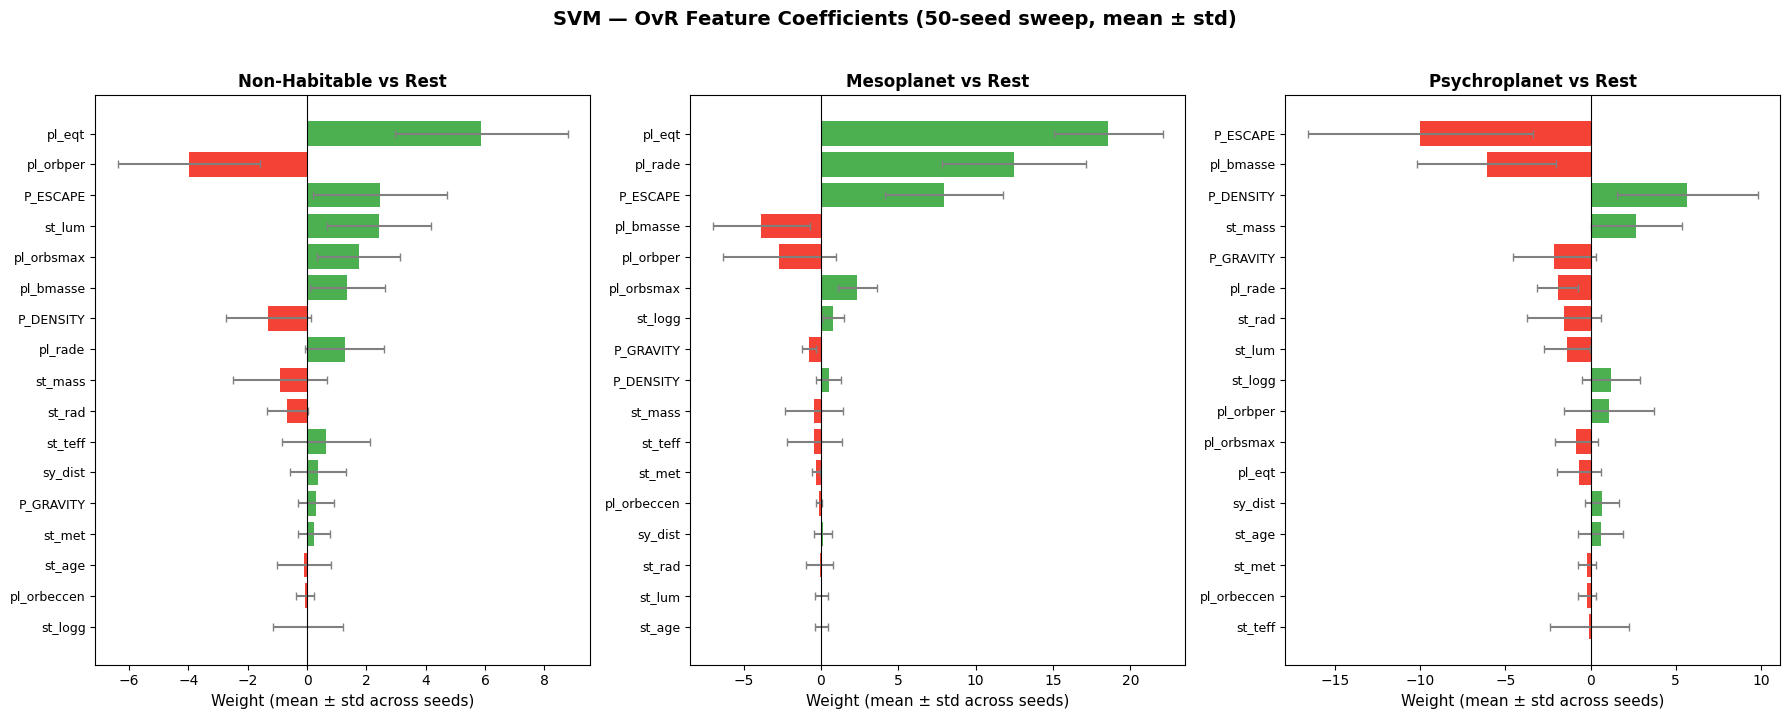

↑ Each panel = the OvR binary classifier 'this class vs the other two'.
  Bar position = mean coefficient across 50 fits. Error bar = std.
  Green = positive (this feature pushes the sample TOWARD this class boundary),
  Red = negative (pushes AWAY). Unlike LDA's discriminant axes, OvR coefficient
  signs are semantically stable across seeds — no sign-flipping ambiguity.
  Wide error bars = unstable feature role across training samples.


In [5]:
plot_sweep_linear_coefficients(sweep_svm)

print("↑ Each panel = the OvR binary classifier 'this class vs the other two'.")
print("  Bar position = mean coefficient across 50 fits. Error bar = std.")
print("  Green = positive (this feature pushes the sample TOWARD this class boundary),")
print("  Red = negative (pushes AWAY). Unlike LDA's discriminant axes, OvR coefficient")
print("  signs are semantically stable across seeds — no sign-flipping ambiguity.")
print("  Wide error bars = unstable feature role across training samples.")

### DIAGNOSTIC PLOT 2: Decision Function Score Distributions by True Class

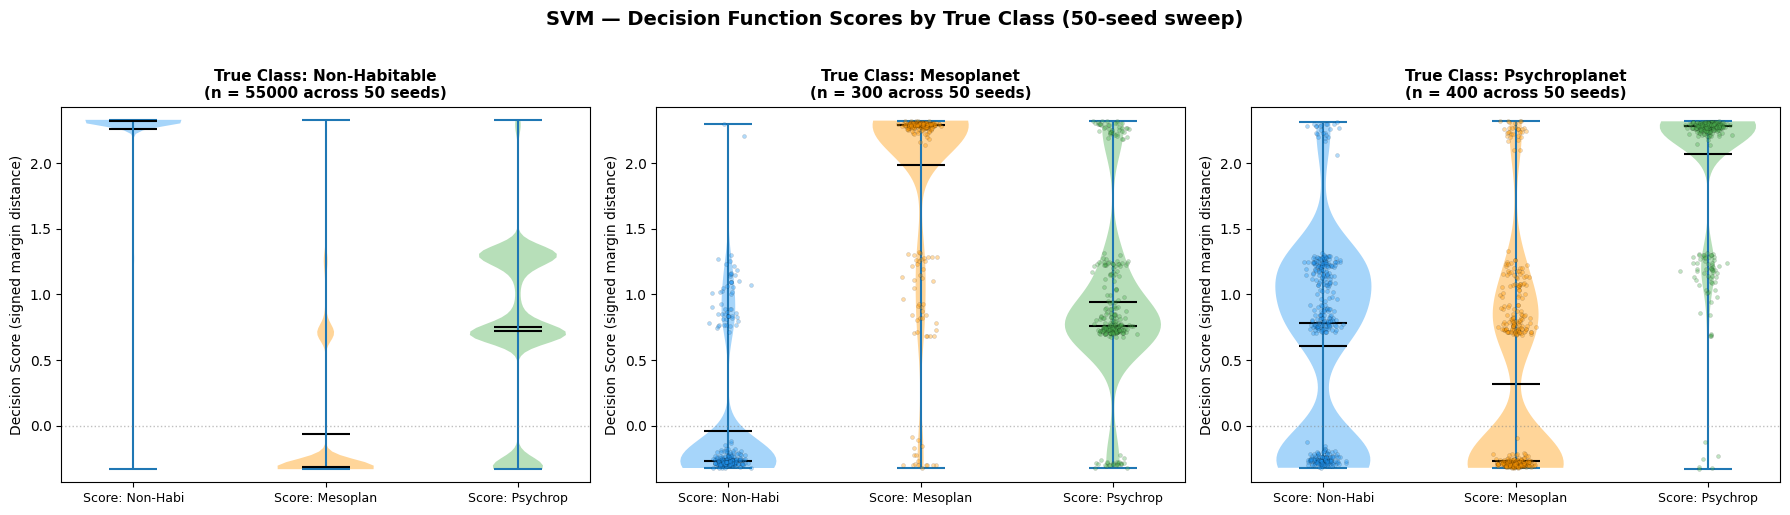

↑ Each panel = decision scores for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300
  score points per minority panel, the violins now have real statistical mass.
  Positive score = model pushes sample toward that class boundary; negative = away.
  For a correctly classified sample, the true class's score should be the highest.
  Score = 0 is the decision boundary; samples near 0 are the most uncertain.


In [6]:
plot_sweep_decision_scores(sweep_svm)

print("↑ Each panel = decision scores for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300")
print("  score points per minority panel, the violins now have real statistical mass.")
print("  Positive score = model pushes sample toward that class boundary; negative = away.")
print("  For a correctly classified sample, the true class's score should be the highest.")
print("  Score = 0 is the decision boundary; samples near 0 are the most uncertain.")

### DIAGNOSTIC PLOT 3: Support Vectors in PCA Space

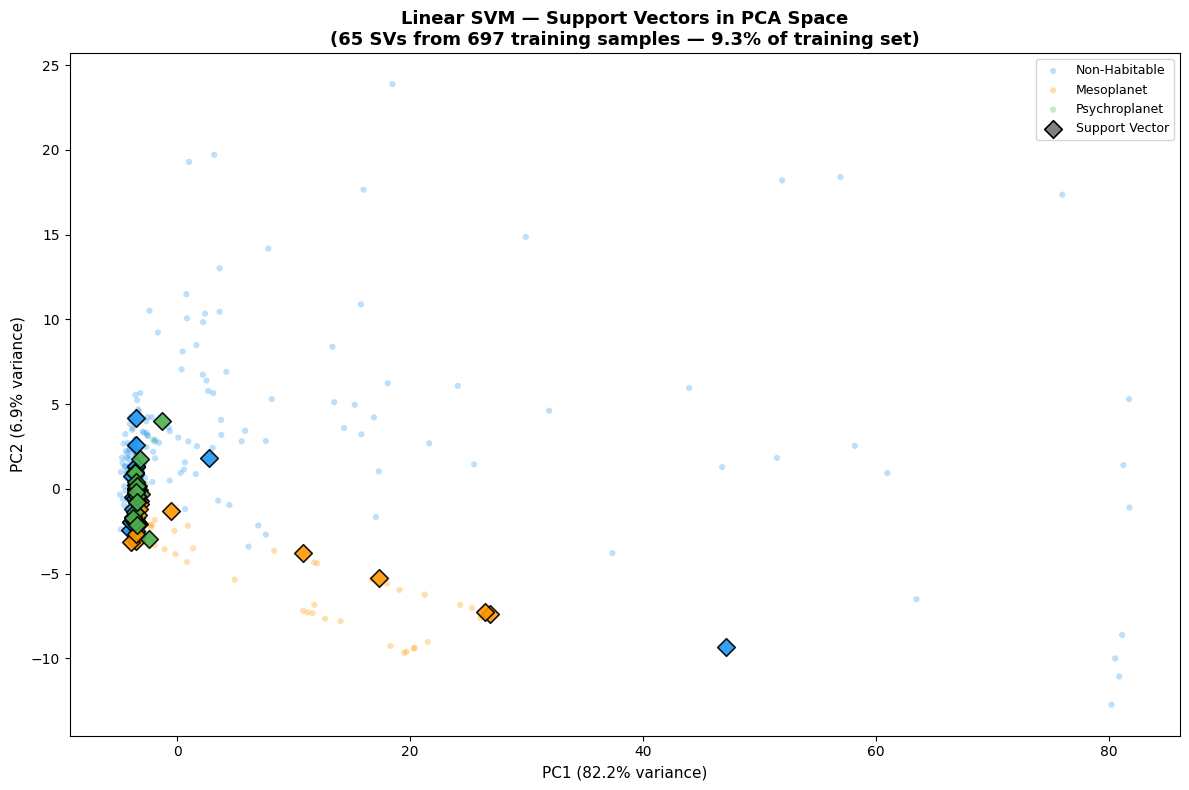

Support vectors per class: {'Non-Habitable': np.int32(22), 'Mesoplanet': np.int32(17), 'Psychroplanet': np.int32(26)}


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)

sv_mask = np.zeros(X_train_bal.shape[0], dtype=bool)
sv_mask[svm_l.support_] = True

y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)

fig, ax = plt.subplots(figsize=(12, 8))

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_train_arr == cls
    ax.scatter(X_train_pca[mask & ~sv_mask, 0], X_train_pca[mask & ~sv_mask, 1],
               c=color, label=label, alpha=0.3, s=20, edgecolors="none")
    ax.scatter(X_train_pca[mask & sv_mask, 0], X_train_pca[mask & sv_mask, 1],
               c=color, s=80, alpha=0.9, edgecolors="black", linewidth=1.2,
               marker="D", zorder=5)

ax.scatter([], [], c="gray", s=80, marker="D", edgecolors="black",
           linewidth=1.2, label="Support Vector")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(
    f"Linear SVM — Support Vectors in PCA Space\n"
    f"({svm_l.n_support_.sum()} SVs from {X_train_bal.shape[0]} training samples — "
    f"{svm_l.n_support_.sum() / X_train_bal.shape[0]:.1%} of training set)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("svm_support_vectors_pca")
plt.show()

print(f"Support vectors per class: {dict(zip(class_names, svm_l.n_support_))}")

## Metrics
### Classification Report

SVM — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9837     0.0040     0.9753     0.9936
Mesoplanet           0.4782     0.1177     0.2500     0.8000
Psychroplanet        0.3409     0.0816     0.1935     0.5161
----------------------------------------------------------------
Macro avg            0.6009     0.0517     0.4962     0.7534
Weighted avg         0.9763     0.0047     0.9670     0.9888

5-Fold CV F1 Macro: 0.9693 ± 0.0179

SVM — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9991 ± 0.0009    0.9688 ± 0.0077
Mesoplanet       0.3509 ± 0.1303    0.8133 ± 0.1770
Psychroplanet    0.2169 ± 0.0596    0.8350 ± 0.1524
----------------------------------------------------------------
Macro avg        0.5223 ± 0.0511    0.8724 ± 0.0737
Wei

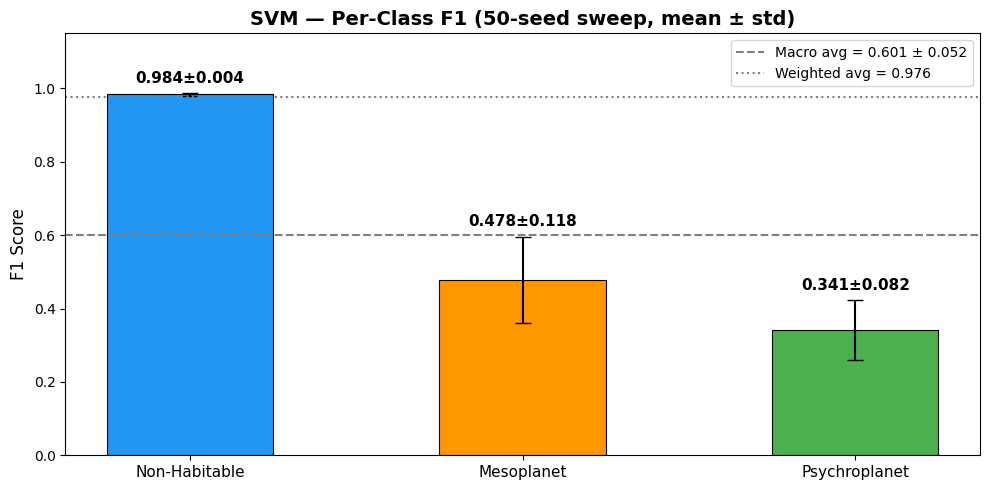

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_svm)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_svm = run_stratified_cv(svm_l, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_svm)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_svm)

### Confusion Matrix (Counts + Normalized)

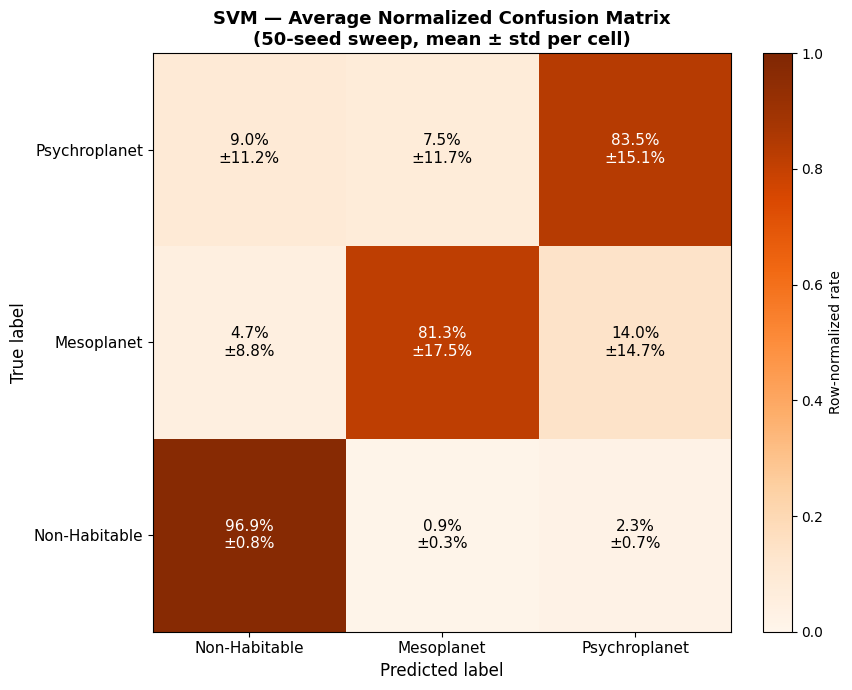

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 9.42 ± 3.76 per split  (0.9% ± 0.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 24.92 ± 7.84 per split  (2.3% ± 0.7% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.28 ± 0.53 per split  (4.7% ± 8.8% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.84 ± 0.88 per split  (14.0% ± 14.7% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.72 ± 0.90 per split  (9.0% ± 11.2% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.60 ± 0.94 per split  (7.5% ± 11.7% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_svm)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_svm)

## Interpretation:
